In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import os
import shutil

source_dir = '/kaggle/input/datasets/kutaykutlu/drowsiness-detection'
output_dir = '/kaggle/working/dataset_split'
categories = ['closed_eye', 'open_eye']
subject_counts = {}

In [ ]:
for category in categories:
    folder_path = os.path.join(source_dir, category)
    
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith(('.png', '.jpg', '.jpeg')):
                subject_id = filename.split('_')[0]
                
                if subject_id not in subject_counts:
                    subject_counts[subject_id] = {'closed_eye': 0, 'open_eye': 0}
                
                subject_counts[subject_id][category] += 1

df_counts = pd.DataFrame.from_dict(subject_counts, orient='index')
df_counts = df_counts.sort_index()

print(df_counts.head())
print(f"Total Subjek Unik: {len(df_counts)}")


In [5]:
val_subjects = ['s0015', 's0019']
test_subjects = ['s0001', 's0003', 's0017', 's0020', 's0029']

for split in ['train', 'val', 'test']:
    for category in categories:
        os.makedirs(os.path.join(output_dir, split, category), exist_ok=True)

counters = {
    'train': {'closed_eye': 0, 'open_eye': 0},
    'val': {'closed_eye': 0, 'open_eye': 0},
    'test': {'closed_eye': 0, 'open_eye': 0}
}

for category in categories:
    category_path = os.path.join(source_dir, category)
        
    for filename in os.listdir(category_path):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            subject_id = filename.split('_')[0]
            
            if subject_id in val_subjects:
                split_folder = 'val'
            elif subject_id in test_subjects:
                split_folder = 'test'
            else:
                split_folder = 'train' 
                
            src_file = os.path.join(category_path, filename)
            dst_file = os.path.join(output_dir, split_folder, category, filename)
            
            shutil.copy2(src_file, dst_file)
            counters[split_folder][category] += 1

for i in ['train', 'val', 'test']:
    print(f"Folder {i.upper()}:")
    print(f"  - Closed Eye : {counters[i]['closed_eye']} gambar")
    print(f"  - Open Eye   : {counters[i]['open_eye']} gambar")


Memulai proses copy gambar ke /kaggle/working/ ...
Folder TRAIN:
  - Closed Eye : 17301 gambar
  - Open Eye   : 16863 gambar
Folder VAL:
  - Closed Eye : 3681 gambar
  - Open Eye   : 3614 gambar
Folder TEST:
  - Closed Eye : 3018 gambar
  - Open Eye   : 3523 gambar


In [15]:
base_dir = '/kaggle/working/dataset_split'
train_dir = f'{base_dir}/train'
val_dir = f'{base_dir}/val'
test_dir = f'{base_dir}/test'

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [17]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

Found 34164 images belonging to 2 classes.
Found 7295 images belonging to 2 classes.
Found 6541 images belonging to 2 classes.


In [18]:
print(f"Urutan Kelas AI: {train_generator.class_indices}")
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Urutan Kelas AI: {'closed_eye': 0, 'open_eye': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774502876.392411      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774502876.398393      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,289 (798.00 KB)

 Trainable params: 204,097 (797.25 KB)

 Non-trainable params: 192 (768.00 B)

In [19]:
# Menyimpan model HANYA saat akurasi validasi membaik
checkpoint = ModelCheckpoint(
    '/kaggle/working/custom_cnn_mata.h5', 
    monitor='val_accuracy', 
    save_best_only=True, 
    mode='max', 
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774502958.403298     206 service.cc:152] XLA service 0x7b6764004410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774502958.403353     206 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774502958.403358     206 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774502958.924280     206 cuda_dnn.cc:529] Loaded cuDNN version 91002


   5/1068 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.5764 - loss: 0.9989

I0000 00:00:1774502962.359278     206 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8654 - loss: 0.3262
Epoch 1: val_accuracy improved from -inf to 0.98862, saving model to /kaggle/working/custom_cnn_mata.h5


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 65s 55ms/step - accuracy: 0.8655 - loss: 0.3262 - val_accuracy: 0.9886 - val_loss: 0.0368
Epoch 2/30
1067/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9546 - loss: 0.1275
Epoch 2: val_accuracy did not improve from 0.98862
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 54s 50ms/step - accuracy: 0.9546 - loss: 0.1275 - val_accuracy: 0.9165 - val_loss: 0.2382
Epoch 3/30
1067/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9687 - loss: 0.0904
Epoch 3: val_accuracy did not improve from 0.98862
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.9688 - loss: 0.0904 - val_accuracy: 0.9494 - val_loss: 0.1501
Epoch 4/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9783 - loss: 0.0680
Epoch 4: val_accuracy improved from 0.98862 to 0.99685, saving model to /kaggle/working/custom_cnn_mata.h5


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.9783 - loss: 0.0680 - val_accuracy: 0.9968 - val_loss: 0.0130
Epoch 5/30
1067/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9819 - loss: 0.0518
Epoch 5: val_accuracy did not improve from 0.99685
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 54s 50ms/step - accuracy: 0.9819 - loss: 0.0518 - val_accuracy: 0.9962 - val_loss: 0.0172
Epoch 6/30
1067/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9851 - loss: 0.0476
Epoch 6: val_accuracy did not improve from 0.99685
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 54s 50ms/step - accuracy: 0.9851 - loss: 0.0476 - val_accuracy: 0.9427 - val_loss: 0.1672
Epoch 7/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9855 - loss: 0.0436
Epoch 7: val_accuracy did not improve from 0.99685
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 54s 50ms/step - accuracy: 0.9855 - loss: 0.0436 - val_accuracy: 0.9966 - val_loss: 0.0148
Epoch 8/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9877 - loss: 0.0370
Epoch 8

1068/1068 ━━━━━━━━━━━━━━━━━━━━ 59s 55ms/step - accuracy: 0.9877 - loss: 0.0370 - val_accuracy: 0.9999 - val_loss: 0.0022
Epoch 9/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9877 - loss: 0.0362
Epoch 9: val_accuracy did not improve from 0.99986
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.9877 - loss: 0.0362 - val_accuracy: 0.9999 - val_loss: 0.0014
Epoch 10/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9880 - loss: 0.0392
Epoch 10: val_accuracy did not improve from 0.99986
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 64s 60ms/step - accuracy: 0.9880 - loss: 0.0392 - val_accuracy: 0.9963 - val_loss: 0.0284
Epoch 11/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9895 - loss: 0.0317
Epoch 11: val_accuracy did not improve from 0.99986
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.9895 - loss: 0.0317 - val_accuracy: 0.9995 - val_loss: 0.0035
Epoch 12/30
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9907 - loss: 0.0278
Ep


=== EVALUASI MODEL DI DATA TESTING ===
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9837 - loss: 0.0472
Akurasi Test: 97.52%


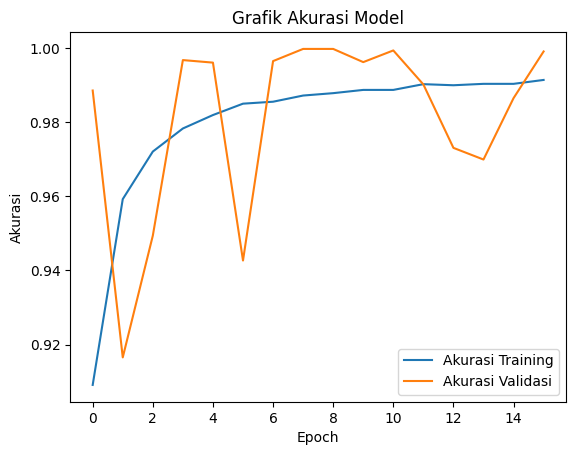


TRAINING SELESAI! Model disimpan sebagai: /kaggle/working/custom_cnn_mata.h5


In [20]:
print("\n=== EVALUASI MODEL DI DATA TESTING ===")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi Test: {test_acc * 100:.2f}%")

plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.title('Grafik Akurasi Model')
plt.ylabel('Akurasi')
plt.xlabel('Epoch')
plt.legend()
plt.show()

print("\nTRAINING SELESAI! Model disimpan sebagai: /kaggle/working/custom_cnn_mata.h5")